# RLVR Results

Run all cells to regenerate the paper figure (fig:RLVR-math) from the W&B runs.


In [1]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict

# Configure matplotlib
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
plt.style.use('seaborn-v0_8-darkgrid')

In [2]:
# ============================================
# Configuration
# ============================================
# Figures are written into the paper root of tables/common.py ($DRPT_PAPER, else ../Paper)
import sys
sys.path.insert(0, os.path.abspath('..'))
from tables.common import paper_root
save_dir = str(paper_root() / 'ICLR' / 'Figures' / 'RLVR')
os.makedirs(save_dir, exist_ok=True)

WANDB_PROJECT = 'verl_grpo_math'
EVAL_METRIC = 'val-aux/DigitalLearningGmbH/MATH-lighteval/reward/mean@1'

ALL_METHODS = ['FullTraining', 'LayerWiseSubset', 'GlobalSubset']

LEGEND_NAMES = {
    'FullTraining': 'Full-Training',
    'LayerWiseSubset': 'Layer-Wise Subset',
    'GlobalSubset': 'Global Subset',
}

METHOD_COLORS = {
    'FullTraining': 'black',
    'LayerWiseSubset': 'red',
    'GlobalSubset': 'green',
}

# W&B run names, one run per method and seed (seed in group 1); same rule as RLVR/tables/accuracy.py
METHOD_PATTERNS = {
    'FullTraining': re.compile(r'^Qwen3-1\.7B_s(\d+)$'),
    'LayerWiseSubset': re.compile(r'^Qwen3-1\.7B_LayerWise_s(\d+)_reward$'),
    'GlobalSubset': re.compile(r'^Qwen3-1\.7B_Global_s(\d+)_reward$'),
}
EXPECTED_SEEDS = 5


## Load the Runs


In [3]:
# ============================================
# Load the runs from W&B and aggregate over seeds
# ============================================
import wandb

def load_run_metric(run, metric_key):
    """(steps, values) of one metric's history, sorted by step."""
    rows = sorted((h['_step'], h[metric_key]) for h in run.scan_history(keys=[metric_key, '_step'], page_size=10000)
                  if h.get(metric_key) is not None)
    return np.array([r[0] for r in rows]), np.array([r[1] for r in rows])

method_runs = defaultdict(dict)   # method -> {seed: run}
for run in wandb.Api().runs(WANDB_PROJECT, per_page=100):
    for method, pattern in METHOD_PATTERNS.items():
        m = pattern.match(run.name)
        if m:
            seed = int(m.group(1))
            assert seed not in method_runs[method], f'two W&B runs match {method} seed {seed}: rename one of them'
            method_runs[method][seed] = run

# all_data[method] = {'steps', 'mean', 'se', 'n_seeds', 'seeds'}; statistics over the rounds every seed evaluated
all_data = {}
for method in ALL_METHODS:
    runs = method_runs[method]
    assert len(runs) == EXPECTED_SEEDS, f'{method}: expected {EXPECTED_SEEDS} seeds, found {sorted(runs)}'
    series = {seed: load_run_metric(run, EVAL_METRIC) for seed, run in sorted(runs.items())}
    common_steps = series[min(series)][0]
    for steps, _ in series.values():
        common_steps = np.intersect1d(common_steps, steps)
    stacked = np.stack([values[np.isin(steps, common_steps)] for steps, values in series.values()])
    all_data[method] = {
        'steps': common_steps,
        'mean': stacked.mean(axis=0),
        'se': stacked.std(axis=0) / np.sqrt(len(series)),
        'n_seeds': len(series),
        'seeds': sorted(series),
    }
    print(f"{method:16s} seeds {sorted(series)}, {len(common_steps)} common evaluations")


wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/user/.netrc.


FullTraining     seeds [2, 22, 42, 62, 82], 58 common evaluations


LayerWiseSubset  seeds [2, 22, 42, 62, 82], 27 common evaluations


GlobalSubset     seeds [2, 22, 42, 62, 82], 37 common evaluations


## Paper Figures: Eval Accuracy vs Round

One plot comparing all methods (first `max_step` rounds). Shaded regions show mean +/- SE across seeds. The lower-right inset zooms on the plateau (last `INSET_X_FRAC` of the plotted rounds). Written straight into the Overleaf clone (`Paper/ICLR/Figures/RLVR/eval_accuracy.pdf` + `legend.pdf`, `fig:RLVR-math`).



  RLVR: Eval Accuracy vs Round
    + FullTraining: 5 seeds, final=0.6303
    + LayerWiseSubset: 5 seeds, final=0.6382
    + GlobalSubset: 5 seeds, final=0.6296


    [inset] rounds [72.0, 78] x accuracy [0.6263, 0.6410]; box 0.45x0.45 in -> inset 1.80x1.80 in (4.0x magnification, box == inset limits)


    -> Saved: Paper/ICLR/Figures/RLVR/eval_accuracy.pdf


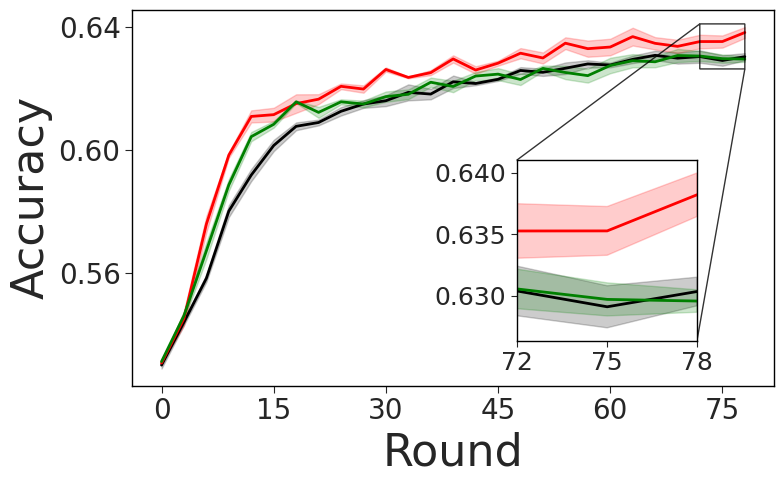


Saved legend: Paper/ICLR/Figures/RLVR/legend.pdf


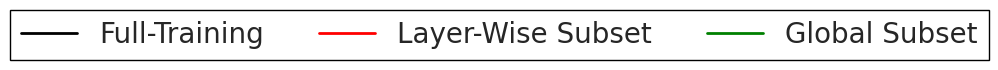

In [4]:
# Paper figure: Eval Accuracy vs Round (fig:RLVR-math)
from matplotlib.ticker import MaxNLocator

max_step = 80  # Set to None for all steps

# FAITHFUL zoom inset: accuracy saturates after ~20 rounds, so the plateau ordering is invisible at the main
# scale while the lower-right corner is empty. The inset is a square (in inches) and the zoom box drawn on the
# main axes has the same display aspect ratio, so the inset is a uniform magnification of the boxed region.
# The window ends at the last plotted round, is centred on the curves (mean +/- SE) inside it, and uses
# magnification INSET_MAX_MAG (lowered only if the curves would not fit). indicate_inset_zoom draws the box at
# the inset's limits.
INSET_H_FRAC = 0.48      # inset side = 48 % of the axes height (square in inches)
INSET_RIGHT = 0.88       # right edge of the inset (axes fraction); left of the box so the connectors slope
INSET_BOTTOM = 0.12      # bottom edge of the inset (axes fraction)
INSET_MAX_MAG = 5.0      # magnification of the inset relative to the main axes
INSET_PAD = 0.08         # y-padding around mean +/- SE inside the zoom window
INSET_FONTSIZE = 18

def _style_axes(ax, labelsize, ticklen):
    """Paper axes style: no grid, black spines, outward ticks."""
    ax.set_facecolor('white')
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.0)
        spine.set_color('black')
    ax.tick_params(axis='both', which='major', labelsize=labelsize, direction='out', length=ticklen)

def _yrange(series, x_min, pad_frac, use_bands=True):
    """Padded [min(mean-se), max(mean+se)] over the series restricted to x >= x_min."""
    lo, hi = [], []
    for steps, mean, se in series:
        m = steps >= x_min
        band = se[m] if (se is not None and use_bands) else 0.0
        lo.append((mean[m] - band).min())
        hi.append((mean[m] + band).max())
    pad = (max(hi) - min(lo)) * pad_frac
    return min(lo) - pad, max(hi) + pad

def _axes_size_in(ax):
    """Axes size in inches (valid once the layout is final)."""
    bb = ax.get_position()
    return bb.width * ax.figure.get_figwidth(), bb.height * ax.figure.get_figheight()

def _square_inset_rect(ax):
    """[x0, y0, w, h] in axes fraction of a square inset with side INSET_H_FRAC * axes height."""
    w_in, h_in = _axes_size_in(ax)
    w_frac = INSET_H_FRAC * h_in / w_in
    return [INSET_RIGHT - w_frac, INSET_BOTTOM, w_frac, INSET_H_FRAC]

def _faithful_window(ax, inset_rect, series, x1):
    """Square zoom window (x0, x1, y0, y1) on `ax` whose box has the same display aspect as the inset
    (uniform magnification). Magnification = INSET_MAX_MAG, lowered only until the fitted curves
    (mean +/- SE) for x >= x0 fit inside the box; the box is centred on them."""
    w_in, h_in = _axes_size_in(ax)
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
    sx, sy = w_in / (xlim[1] - xlim[0]), h_in / (ylim[1] - ylim[0])   # inches per data unit
    inset_in = (inset_rect[2] * w_in, inset_rect[3] * h_in)
    m = INSET_MAX_MAG
    while True:
        dx, dy = inset_in[0] / (m * sx), inset_in[1] / (m * sy)          # box size in data units
        x0 = x1 - dx
        lo, hi = _yrange(series, x_min=x0, pad_frac=INSET_PAD, use_bands=True)
        if hi - lo <= dy or m <= 1.0:
            break
        m *= 0.98
    yc = (lo + hi) / 2
    return (x0, x1, yc - dy / 2, yc + dy / 2), (dx * sx, dy * sy), inset_in, m

print(f"\n{'='*60}")
print(f"  RLVR: Eval Accuracy vs Round")
print(f"{'='*60}")

# Truncate to max_step once.
plotted = {}
for method in ALL_METHODS:
    if method not in all_data:
        print(f"    - {method}: no data")
        continue
    data = all_data[method]
    steps, mean, se = data['steps'], data['mean'], data['se']
    if max_step is not None:
        mask = steps <= max_step
        steps, mean, se = steps[mask], mean[mask], se[mask]
    plotted[method] = (steps, mean, se if data['n_seeds'] > 1 else None)

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('white')

for method, (steps, mean, se) in plotted.items():
    ax.plot(steps, mean, linewidth=2, color=METHOD_COLORS[method], label=LEGEND_NAMES[method])
    if se is not None:
        ax.fill_between(steps, mean - se, mean + se, color=METHOD_COLORS[method], alpha=0.2)
    print(f"    + {method}: {all_data[method]['n_seeds']} seeds, final={mean[-1]:.4f}")

ax.set_xlabel('Round', fontsize=32)
ax.set_ylabel('Accuracy', fontsize=32)
_style_axes(ax, labelsize=20, ticklen=5)
ax.xaxis.set_major_locator(MaxNLocator(6))
# Tick steps restricted to multiples of 0.01/0.02/0.04/0.05 so the 2-decimal labels are exact (0.025 steps would print 0.53/0.57/0.62).
ax.yaxis.set_major_locator(MaxNLocator(nbins=6, steps=[1, 2, 4, 5, 10]))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.2f}'))

# Final layout BEFORE the inset (its geometry depends on the final axes size)
fig.tight_layout()

if plotted:
    inset_rect = _square_inset_rect(ax)
    axins = ax.inset_axes(inset_rect)
    for method, (steps, mean, se) in plotted.items():
        axins.plot(steps, mean, linewidth=2, color=METHOD_COLORS[method])
        if se is not None:
            axins.fill_between(steps, mean - se, mean + se, color=METHOD_COLORS[method], alpha=0.2)
    x1 = max(s.max() for s, _, _ in plotted.values())
    (ix0, ix1, iy0, iy1), box_in, inset_in, mag = _faithful_window(ax, inset_rect, list(plotted.values()), x1=x1)
    axins.set_xlim(ix0, ix1)
    axins.set_ylim(iy0, iy1)
    _style_axes(axins, labelsize=INSET_FONTSIZE, ticklen=4)
    axins.xaxis.set_major_locator(MaxNLocator(3, integer=True))
    axins.yaxis.set_major_locator(MaxNLocator(nbins=3, steps=[1, 2, 4, 5, 10]))
    axins.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.3f}'))   # window spans ~0.01 -> 3 decimals
    # indicate_inset_zoom draws the box at the inset's data limits (in parent data coords)
    indicator = ax.indicate_inset_zoom(axins, edgecolor='black', alpha=0.8, linewidth=1.0)
    rect = indicator.rectangle if hasattr(indicator, 'rectangle') else indicator[0]   # mpl >= 3.10 / older
    box = (rect.get_x(), rect.get_y(), rect.get_x() + rect.get_width(), rect.get_y() + rect.get_height())
    assert np.allclose(box, (ix0, iy0, ix1, iy1)), box
    # Faithfulness: box and inset have the same display aspect -> uniform magnification
    assert abs(box_in[0] / box_in[1] - inset_in[0] / inset_in[1]) < 1e-3, (box_in, inset_in)
    print(f"    [inset] rounds [{ix0:.1f}, {ix1}] x accuracy [{iy0:.4f}, {iy1:.4f}]; "
          f"box {box_in[0]:.2f}x{box_in[1]:.2f} in -> inset {inset_in[0]:.2f}x{inset_in[1]:.2f} in "
          f"({mag:.1f}x magnification, box == inset limits)")
else:
    ax.text(0.5, 0.5, 'No data', transform=ax.transAxes, ha='center', fontsize=24, color='gray')

filepath = os.path.join(save_dir, 'eval_accuracy.pdf')
fig.savefig(filepath, format='pdf', bbox_inches='tight', facecolor='white')
print(f"    -> Saved: {filepath}")
plt.show()

# Save a standalone legend figure
legend_labels = [LEGEND_NAMES[m] for m in ALL_METHODS]
legend_colors = [METHOD_COLORS[m] for m in ALL_METHODS]

fig_leg, ax_leg = plt.subplots(figsize=(6, 0.5))
ax_leg.set_axis_off()
handles = [plt.Line2D([0], [0], color=c, linewidth=2) for c in legend_colors]
legend = fig_leg.legend(handles, legend_labels, loc='center', ncol=len(legend_labels),
                        fontsize=20, frameon=True, edgecolor='black', fancybox=False, framealpha=1.0)
legend.get_frame().set_facecolor('white')
fig_leg.patch.set_facecolor('white')
filepath = os.path.join(save_dir, 'legend.pdf')
fig_leg.savefig(filepath, format='pdf', bbox_inches='tight', facecolor='white')
print(f"\nSaved legend: {filepath}")
plt.show()
